# PREPROCESAMIENTO DE LOS DATOS

Vamos a realizar un preprocesamiento de los datos

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, TargetEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, make_scorer, f1_score, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.utils import compute_class_weight
from scipy.stats import randint, uniform, loguniform
import joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import pickle 
import warnings
warnings.filterwarnings('ignore') 

## LIMPIEZA DE LOS DATOS

Vamos a realizar el tratamiento de nulos. 

In [27]:
df = pd.read_csv("../data/raw/bs140513_032310.csv",delimiter=";")

In [28]:
df.head()

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


In [29]:
df.shape

(594643, 10)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  str    
 2   age          594643 non-null  str    
 3   gender       594643 non-null  str    
 4   zipcodeOri   594643 non-null  str    
 5   merchant     594643 non-null  str    
 6   zipMerchant  594643 non-null  str    
 7   category     594643 non-null  str    
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 45.4 MB


In [31]:
df.isnull().sum()

step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64

In [32]:
valores_unicos = {col: df[col].unique() for col in df.columns}
for col, vals in valores_unicos.items():
    print(f"{col}: {vals}")

step: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179]
customer: <StringArray>
[''C1093826151'',  ''C352968107'', ''C2054744914'', ''C1760612790'',
  ''C757503768'', ''C1315400589'',  ''C765155274'',  ''C202531238'',
  ''C105845174'',   ''C39858251'',
 ...
 ''C1468001998'',  ''C762865358'',   ''C20027851'', ''C123918

step: tiempo, probablemnete en horas y nos permite captar patrones temporales. 
zipcodeori: la borramos ¿¿??
category: que hacemos con category ??? onehot ? 


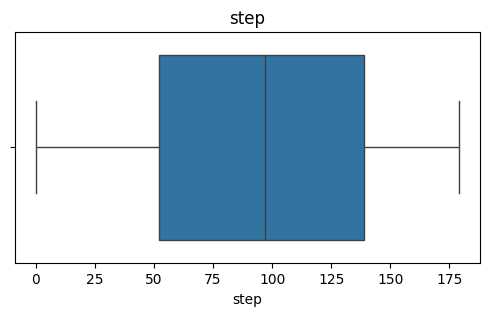

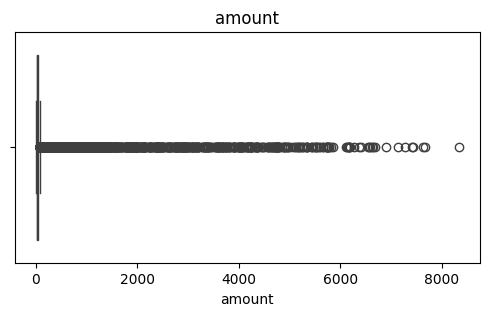

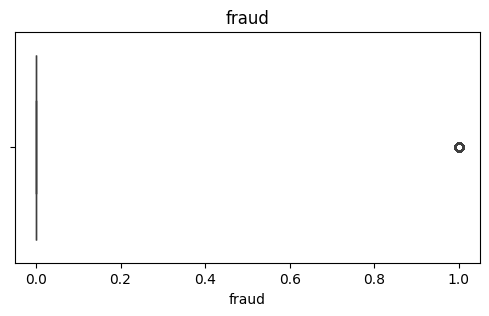

In [33]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Este código detecta valores extremos en amount usando el método IQR y cuenta cuántos registros son outliers respecto al total del dataset.
Calcula primer y tercer cuartil, el rango intercuartilico y define los límites de outliers. 

In [34]:
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["amount"] < lower) | (df["amount"] > upper)]

print(len(outliers))
print(len(df))

25798
594643


In [35]:
outliers["fraud"].value_counts(normalize=True)
df["fraud"].value_counts(normalize=True)

fraud
0    0.987892
1    0.012108
Name: proportion, dtype: float64

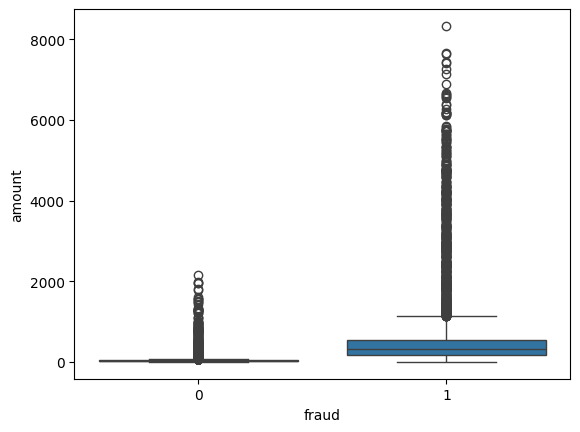

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="fraud", y="amount", data=df)
plt.show()

Hay casos de fraude en valores extremos de amount, se pueden interpretar como outliers. Sin embargo, nosotros decimos no tratarlo porque se trata de un valor extremo en los casos de fraude y es por tanto objeto de nuestra investigación. 

### ENCODING

Vamos a hacer ONE HOT ENCODING en la variable age y para gender.

La variable age, aunque contiene valores numéricos, representa categorías de rangos de edad y no una variable continua. Tratarla como numérica implicaría asumir relaciones de orden y distancia que no son necesariamente correctas.
Para evitar este problema, se aplica One-Hot Encoding, que transforma cada categoría en una variable binaria independiente. De este modo, el modelo no asume relaciones entre categorías y puede capturar mejor su efecto.
Además, se mantiene la categoría unknown (U), ya que los valores desconocidos pueden aportar información relevante en la detección de fraude.

Para gender se podría hacer, pero no se si tiene sentido ni incluirla en el modelo, podemos probar y luego mirar model.feature_importances_

Se hará en la parte de modelaje, one hot encoding para ambas variables en un Pipeline. A continuación se dejan preparadas. 

In [37]:
df["age"] = df["age"].str.replace("'", "")
df["age"] = df["age"].replace("U", "unknown")

In [38]:
df["gender"] = df["gender"].str.replace("'", "")
df["gender"] = df["gender"].replace("U", "unknown")

## FEATURE ENGINEERING

Features que deberiamos hacer para nuestro caso de fraude: 
- High amount (pueden ser transacciones sospechosas): es util porque el fraude suele intentar importes muy altos o son importes "raros" y así se captura directamente. El codigo calcula el percentil 95 de amount, es decir, encuentra el valor por debajo del cual está el 95% de las transacciones. Se crea una nueva columna, y si amount es mayor que el threshold. marca 1, sino 0.
En resumen, este código crea una variable que indica si una transacción pertenece al 5% de importes más altos del dataset, marcándola como potencialmente sospechosa.

In [39]:
threshold = df["amount"].quantile(0.95)
df["high_amount"] = (df["amount"] > threshold).astype(int)

-La variable step representa unidades temporales equivalentes a días dentro de la simulación, por lo que se emplea para capturar la evolución temporal del comportamiento y se transforma en variables como el día de la semana para identificar patrones cíclicos.
Creamos día de la semana: porque el fraude cambia entre semana y fin de semana y el comportamiento puede ser distinto. 
Se emplea una transformación cíclica mediante funciones seno y coseno para representar la naturaleza periódica del tiempo, permitiendo capturar patrones semanales sin introducir discontinuidades artificiales.

In [40]:
df["day_of_week_sin"] = np.sin(2 * np.pi * df["step"] / 7)
df["day_of_week_cos"] = np.cos(2 * np.pi * df["step"] / 7)

- Frecuencia de merchant: detecta merchants muy usados (normales) o merchants raros (sospechosos).
Crea una nueva variable (merchant_freq) que indica qué tan frecuente o raro es cada merchant:
valores altos --> merchants muy comunes
valores bajos --> merchants poco frecuentes (más raros)

In [41]:
df["merchant_freq"] = df["merchant"].map(df["merchant"].value_counts())

Ahora vamos a eliminar las variables zipcodeOri y zipMerchant, porque contienen un unico valor para todos los registros y no nos proporcionan información. 
Además, eliminamos a continuación la variable step tras realizar el tratamiento de future engineering ya que consta la misma como day_of_week_sin y day_of_week_cos

In [42]:
df = df.drop("zipcodeOri", axis=1)
df = df.drop("zipMerchant", axis=1)
df = df.drop("step", axis=1)

In [43]:
df.head(20)

,customer,age,gender,merchant,category,amount,fraud,high_amount,day_of_week_sin,day_of_week_cos,merchant_freq
0,'C1093826151',4,M,'M348934600','es_transportation',4.55,0,0,0.0,1.0,205426
1,'C352968107',2,M,'M348934600','es_transportation',39.68,0,0,0.0,1.0,205426
2,'C2054744914',4,F,'M1823072687','es_transportation',26.89,0,0,0.0,1.0,299693
3,'C1760612790',3,M,'M348934600','es_transportation',17.25,0,0,0.0,1.0,205426
4,'C757503768',5,M,'M348934600','es_transportation',35.72,0,0,0.0,1.0,205426
5,'C1315400589',3,F,'M348934600','es_transportation',25.81,0,0,0.0,1.0,205426
6,'C765155274',1,F,'M348934600','es_transportation',9.10,0,0,0.0,1.0,205426
7,'C202531238',4,F,'M348934600','es_transportation',21.17,0,0,0.0,1.0,205426
8,'C105845174',3,M,'M348934600','es_transportation',32.40,0,0,0.0,1.0,205426
9,'C39858251',5,F,'M348934600','es_transportation',35.40,0,0,0.0,1.0,205426


## Separación en train y test:

A continuación, creamos una carpeta para almacenar los datos limpios y separa el dataset en variables explicativas (X) y variable objetivo (y), fraude. La variable fraud se elimina de X y se guarda por separado en y.
Finalmente, ambos conjuntos se guardan en archivos CSV para poder reutilizarlos fácilmente en fases posteriores del análisis del trabajo.

In [44]:
from pathlib import Path
import pandas as pd

# Crear carpeta data/clean (si no existe)
clean_path = Path("../data/clean")
clean_path.mkdir(parents=True, exist_ok=True)

X = df.drop("fraud", axis=1)
y = df["fraud"]

# Guardar datasets
X.to_csv(clean_path / "X_clean.csv", index=False)
y.to_csv(clean_path / "y.csv", index=False)

print("Datos guardados en data/clean/")

Datos guardados en data/clean/
